In [ ]:
## Notebook to practice using Iris 

In [ ]:
import iris


In [3]:
filename = iris.sample_data_path('uk_hires.pp')
cubes = iris.load(filename)
print(cubes)

0: air_potential_temperature / (K)     (time: 3; model_level_number: 7; grid_latitude: 204; grid_longitude: 187)
1: surface_altitude / (m)              (grid_latitude: 204; grid_longitude: 187)


/home/jj22956/.local/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


In [4]:
air_potential_temperature = cubes[0]
print(air_potential_temperature)

air_potential_temperature / (K)     (time: 3; model_level_number: 7; grid_latitude: 204; grid_longitude: 187)
    Dimension coordinates:
        time                             x                      -                 -                    -
        model_level_number               -                      x                 -                    -
        grid_latitude                    -                      -                 x                    -
        grid_longitude                   -                      -                 -                    x
    Auxiliary coordinates:
        forecast_period                  x                      -                 -                    -
        level_height                     -                      x                 -                    -
        sigma                            -                      x                 -                    -
        surface_altitude                 -                      -                 x                  

/home/jj22956/.local/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


In [5]:
filenames = [iris.sample_data_path('uk_hires.pp'), 
             iris.sample_data_path('air_temp.pp')]
cubes = iris.load(filename)
print(cubes)

0: air_potential_temperature / (K)     (time: 3; model_level_number: 7; grid_latitude: 204; grid_longitude: 187)
1: surface_altitude / (m)              (grid_latitude: 204; grid_longitude: 187)


/home/jj22956/.local/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


In [6]:
filename = iris.sample_data_path('uk_hires.pp')
cubes = iris.load(filename, 'surface_altitude')
print(cubes)

0: surface_altitude / (m)              (grid_latitude: 204; grid_longitude: 187)


In [7]:
filename = iris.sample_data_path('uk_hires.pp')
cubes = iris.load(filename, 'm01s00i033')
print(cubes)

0: surface_altitude / (m)              (grid_latitude: 204; grid_longitude: 187)


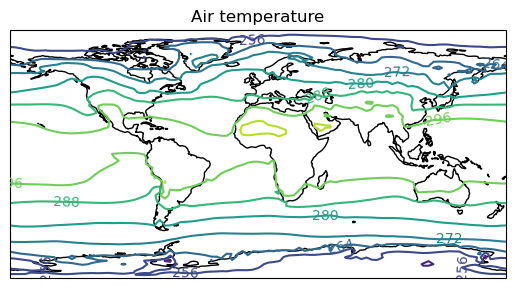

In [8]:
import matplotlib.pyplot as plt
import iris.quickplot as qplt

fname = iris.sample_data_path("air_temp.pp")
temperature_cube = iris.load_cube(fname)

# Add a contour, and put the result in a variable called contour.
contour = qplt.contour(temperature_cube)

# Add coastlines to the map created by contour.
plt.gca().coastlines()

# Add contour labels based on the contour we have just created.
plt.clabel(contour, inline=False)

plt.show()

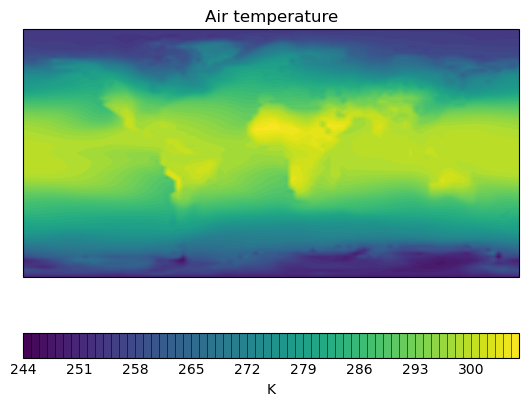

In [ ]:
# Plotting a filled contour plot
fname = iris.sample_data_path("air_temp.pp")
temperature_cube = iris.load_cube(fname)
qplt.contourf(temperature_cube, 60)

plt.savefig('figures/earth_air_temp_filled_contours')
plt.show()

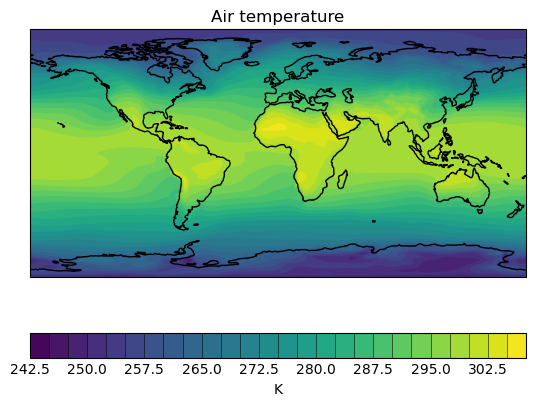

In [18]:
# Plotting a filled contour plot
qplt.contourf(temperature_cube, 25)

# Add coastlines to the map created by contourf.
plt.gca().coastlines()
plt.savefig('figures/earth_air_temp_filled_contours_with_coast')
plt.show()

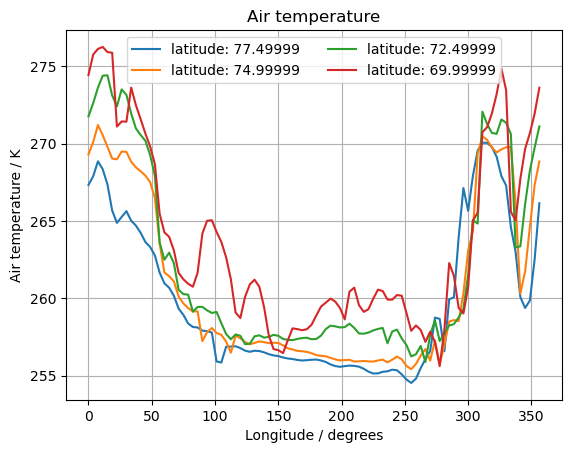

In [19]:
"""
Multi-Line Temperature Profile Plot
===================================

"""  # noqa: D205, D212, D400

import matplotlib.pyplot as plt

import iris
import iris.plot as iplt
import iris.quickplot as qplt


def main():
    fname = iris.sample_data_path("air_temp.pp")

    # Load exactly one cube from the given file.
    temperature = iris.load_cube(fname)

    # We only want a small number of latitudes, so filter some out
    # using "extract".
    temperature = temperature.extract(
        iris.Constraint(latitude=lambda cell: 68 <= cell < 78)
    )

    for cube in temperature.slices("longitude"):
        # Create a string label to identify this cube (i.e. latitude: value).
        cube_label = "latitude: %s" % cube.coord("latitude").points[0]

        # Plot the cube, and associate it with a label.
        qplt.plot(cube, label=cube_label)

    # Add the legend with 2 columns.
    plt.legend(ncol=2)

    # Put a grid on the plot.
    plt.grid(True)

    # Tell matplotlib not to extend the plot axes range to nicely
    # rounded numbers.
    plt.axis("tight")

    # Finally, show it.
    iplt.show()


if __name__ == "__main__":
    main()